
TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Valor máximo de píxeles blancos en filas: 220
Umbral del 90%: 198.00
Número de filas que cumplen la condición: 7
Posiciones de las filas: [6, 12, 15, 20, 21, 88, 100]


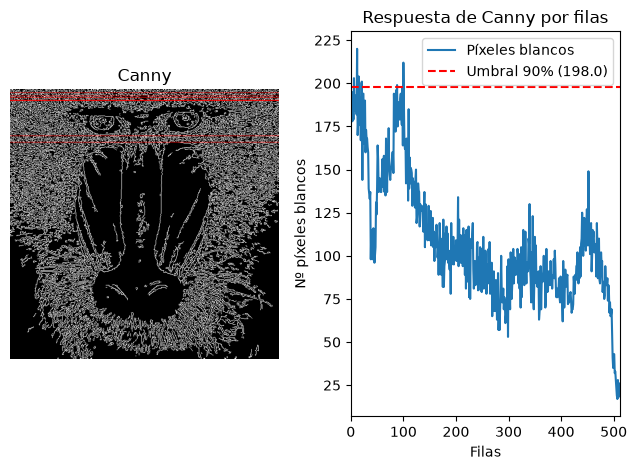

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Lee imagen de archivo
img = cv2.imread('mandril.jpg')
#Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#Obtener contornos con el operador de Canny
canny = cv2.Canny(gris, 100, 200)

#Suma los valores de los pixeles por fila
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Píxeles blancos por fila
filas = (row_counts.flatten() / 255).astype(int) 

#Valor máximo
maxfil = np.max(filas)
#Umbral
umbral = 0.90 * maxfil

#Filas con número de píxeles blancos mayores o iguales al umbral
filas_umbral = np.where(filas >= umbral)[0]

print(f"Valor máximo de píxeles blancos en filas: {maxfil}")
print(f"Umbral del 90%: {umbral:.2f}")
print(f"Número de filas que cumplen la condición: {len(filas_umbral)}")
print(f"Posiciones de las filas: {filas_umbral.tolist()}")

#Convierte Canny a 3 canales para poder trazar líneas de color visible
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
ancho = canny.shape[1]

#Dibuja las lineas
for y in filas_umbral:
    cv2.line(canny_color, (0, y), (ancho - 1, y), (255, 0, 0), 1)

# Imagen de Canny con las filas resaltadas
plt.subplot(1, 2, 1)
plt.title("Canny")
plt.axis("off")
plt.imshow(canny_color)

# Gráfico del conteo por filas
plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny por filas")
plt.xlabel("Filas")
plt.ylabel("Nº píxeles blancos")
plt.plot(filas, label='Píxeles blancos')
plt.axhline(y=umbral, color='r', linestyle='--', label=f'Umbral 90% ({umbral:.1f})')
plt.xlim([0, canny.shape[0]])
plt.legend()
plt.tight_layout()
plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Preparación y detección de bordes
img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
alto, ancho = gris.shape

# Canny
canny = cv2.Canny(gris, 100, 200)

# Sobel umbralizado
ggris = cv2.GaussianBlur(gris, (3, 3), 0)
sobel = cv2.add(cv2.Sobel(ggris, cv2.CV_64F, 1, 0), cv2.Sobel(ggris, cv2.CV_64F, 0, 1))
_, sobel_u = cv2.threshold(cv2.convertScaleAbs(sobel), 60, 255, cv2.THRESH_BINARY)

# Conteo por filas y columnas
fil_c = (cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() / 255).astype(int)
col_c = (cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() / 255).astype(int)

fil_s = (cv2.reduce(sobel_u, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() / 255).astype(int)
col_s = (cv2.reduce(sobel_u, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten() / 255).astype(int)

# Filas y columnas >= 0.90 * máximo
fil_c_90 = np.where(fil_c >= 0.90 * np.max(fil_c))[0]
col_c_90 = np.where(col_c >= 0.90 * np.max(col_c))[0]

fil_s_90 = np.where(fil_s >= 0.90 * np.max(fil_s))[0]
col_s_90 = np.where(col_s >= 0.90 * np.max(col_s))[0]

# Dibujar líneas sobre la imagen (filas verdes, columnas azules)
img_canny = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)
img_sobel = cv2.cvtColor(img.copy(), cv2.COLOR_BGR2RGB)

for y in fil_c_90: cv2.line(img_canny, (0, y), (ancho - 1, y), (255, 0, 0), 2)
for x in col_c_90: cv2.line(img_canny, (x, 0), (x, alto - 1), (0, 0, 255), 2)

for y in fil_s_90: cv2.line(img_sobel, (0, y), (ancho - 1, y), (255, 0, 0), 2)
for x in col_s_90: cv2.line(img_sobel, (x, 0), (x, alto - 1), (0, 0, 255), 2)

# Visualización de bordes
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1); plt.title("Canny"); plt.axis("off"); plt.imshow(canny, cmap='gray')
plt.subplot(2, 2, 2); plt.title("Sobel Umbralizado"); plt.axis("off"); plt.imshow(sobel_u, cmap='gray')
plt.subplot(2, 2, 3); plt.title(f"Líneas Canny (F:{len(fil_c_90)}, C:{len(col_c_90)})"); plt.axis("off"); plt.imshow(img_canny)
plt.subplot(2, 2, 4); plt.title(f"Líneas Sobel (F:{len(fil_s_90)}, C:{len(col_s_90)})"); plt.axis("off"); plt.imshow(img_sobel)
plt.tight_layout()
plt.show()

# Gráficos
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Canny")
plt.plot(fil_c, 'r', label='Filas'); plt.axhline(0.90 * np.max(fil_c), color='r', linestyle='--')
plt.plot(col_c, 'b', label='Cols'); plt.axhline(0.90 * np.max(col_c), color='b', linestyle='--')
plt.legend()

plt.subplot(1, 2, 2)
plt.title("Sobel")
plt.plot(fil_s, 'r', label='Filas'); plt.axhline(0.90 * np.max(fil_s), color='r', linestyle='--')
plt.plot(col_s, 'b', label='Cols'); plt.axhline(0.90 * np.max(col_s), color='b', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


TAREA: Tras ver los vídeos My little piece of privacy, Messa di voce y Virtual air guitar proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
import cv2
import numpy as np
import random
import time   # <--- 1. Importamos time para el cronómetro

# Iniciar captura de webcam
vid = cv2.VideoCapture(0)

# Sustractor de fondo (guion P2)
eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=35, detectShadows=False)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Variables del juego
puntos = 0
vidas = 3
radio_bola = 16

# <--- 2. Parámetros del temporizador de inicio
tiempo_inicio = time.time()
segundos_inmune = 4  # 4 segundos de protección al empezar

num_bolas = 5
bolas = []

def nueva_bola(ancho):
    """Crea una bola arriba; 30% de probabilidad de ser 'mala'"""
    x = random.randint(30, ancho - 30)
    velocidad = random.randint(5, 8)
    tipo = 'mala' if random.random() < 0.3 else 'buena'
    return [x, 0, velocidad, tipo]

print("¡Demostrador iniciado! Tienes 4 segundos de protección al arrancar.")

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # Efecto espejo
    frame = cv2.flip(frame, 1)
    alto, ancho, _ = frame.shape

    # <--- 3. Comprobar si aún estamos dentro del tiempo de protección
    tiempo_transcurrido = time.time() - tiempo_inicio
    es_inmune = tiempo_transcurrido < segundos_inmune

    # Inicializar bolas la primera vez
    if len(bolas) == 0:
        for _ in range(num_bolas):
            bolas.append(nueva_bola(ancho))

    # Sustracción de fondo y morfología
    mascara = eliminadorFondo.apply(frame)
    mascara_limpia = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara_limpia = cv2.dilate(mascara_limpia, kernel, iterations=2)

    toco_buena = False
    toco_mala = False

    # Actualizar bolas y colisiones
    if vidas > 0:
        for b in bolas:
            b[1] += b[2]
            bx, by = int(b[0]), int(b[1])
            tipo = b[3]

            # Detección de impacto sobre la silueta
            if 0 <= by < alto and 0 <= bx < ancho:
                if mascara_limpia[by, bx] == 255:
                    if tipo == 'buena':
                        puntos += 1
                        toco_buena = True
                        b[0], b[1], b[2], b[3] = nueva_bola(ancho)
                    else:  # Bola mala
                        # <--- 4. Solo resta vida si se acabó el tiempo de protección
                        if not es_inmune:
                            vidas -= 1
                            toco_mala = True
                        # Reaparece arriba igualmente para que no se quede atascada
                        b[0], b[1], b[2], b[3] = nueva_bola(ancho)

            # Si llega al suelo, reaparece arriba
            if b[1] >= alto:
                b[0], b[1], b[2], b[3] = nueva_bola(ancho)

    # Dibujar las bolas
    for b in bolas:
        bx, by = int(b[0]), int(b[1])
        tipo = b[3]
        if tipo == 'buena':
            cv2.circle(frame, (bx, by), radio_bola, (0, 220, 0), -1)
            cv2.circle(frame, (bx, by), radio_bola - 6, (255, 255, 255), -1)
        else:
            cv2.circle(frame, (bx, by), radio_bola, (0, 0, 255), -1)
            cv2.circle(frame, (bx, by), radio_bola - 6, (50, 50, 200), -1)

    # Destellos de impacto
    if toco_buena:
        cv2.rectangle(frame, (0, 0), (ancho, alto), (0, 255, 0), 8)
    elif toco_mala:
        cv2.rectangle(frame, (0, 0), (ancho, alto), (0, 0, 255), 10)

    # Marcadores
    cv2.putText(frame, f"Puntos: {puntos}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    cv2.putText(frame, f"Vidas: {vidas}", (ancho - 150, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # <--- 5. Mensaje visual del temporizador mientras esté activo
    if es_inmune:
        seg_restantes = int(segundos_inmune - tiempo_transcurrido) + 1
        cv2.putText(frame, f"INMUNE: {seg_restantes}s", (ancho // 2 - 90, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

    # Pantalla Game Over
    if vidas <= 0:
        cv2.putText(frame, "GAME OVER", (ancho // 2 - 140, alto // 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 255), 3)
        cv2.putText(frame, "Pulsa ESC para salir", (ancho // 2 - 120, alto // 2 + 45),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    cv2.imshow('Lluvia de Objetos Interactiva (Demostrador P2)', frame)
    cv2.imshow('Mascara Movimiento (MOG2)', mascara_limpia)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

¡Demostrador iniciado! Tienes 4 segundos de protección al arrancar.
